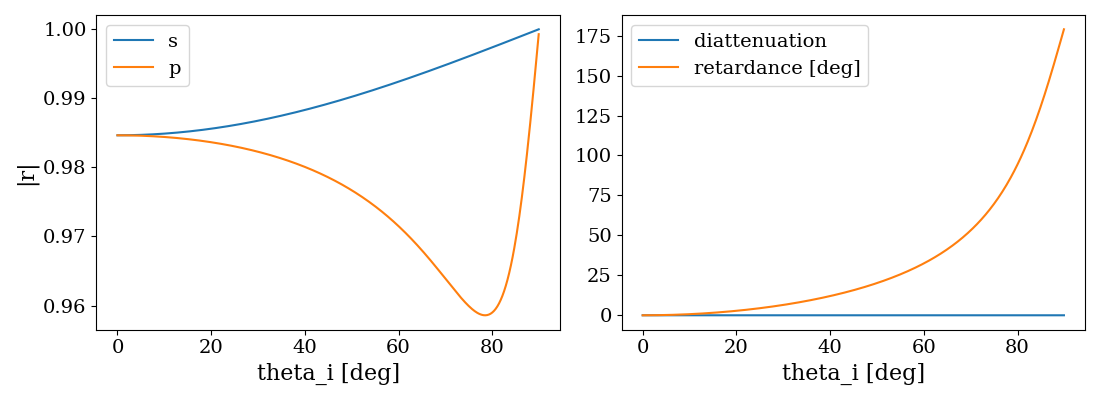

In [9]:
#this whole notebook is claude. don't trust it, but may be helpful to give guidlines for what to measure

import numpy as np
import matplotlib.pyplot as plt

%matplotlib widget
plt.rc('font', family='serif')
plt.rc('xtick', labelsize=14)
plt.rc('ytick', labelsize=14)
plt.rc('axes', titlesize=16, labelsize=16)
plt.rc('legend', fontsize=14)
plt.rc('figure', titlesize=18)


n_metal =.207 + 5.07j       #gold 852
theta = np.radians(np.linspace(0, 89.9, 500))

q = np.sqrt(n_metal**2 - np.sin(theta)**2)
q = np.where(q.real < 0, -q, q)
r_s = (np.cos(theta) - q) / (np.cos(theta) + q)
r_p = (n_metal**2 * np.cos(theta) - q) / (n_metal**2 * np.cos(theta) + q)

phi_s = np.angle(r_s)
phi_p = np.unwrap(np.pi + np.angle(r_p))
D = (abs(r_s)**2 - abs(r_p)**2) / (abs(r_s)**2 + abs(r_p)**2)
delta = phi_p - phi_s

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(np.degrees(theta), abs(r_s), label='s')
ax[0].plot(np.degrees(theta), abs(r_p), label='p')
ax[0].set_xlabel('theta_i [deg]'); ax[0].set_ylabel('|r|'); ax[0].legend()
ax[1].plot(np.degrees(theta), D, label='diattenuation')
ax[1].plot(np.degrees(theta), np.degrees(delta-2*np.pi), label='retardance [deg]')
ax[1].set_xlabel('theta_i [deg]'); ax[1].legend()
plt.tight_layout()

critical angle      41.47 deg   (margin at 45 deg fold: 3.53 deg)
retardance at 45    38.70 deg
peak retardance     45.95 deg at 51.31 deg  (Fresnel rhomb angle)


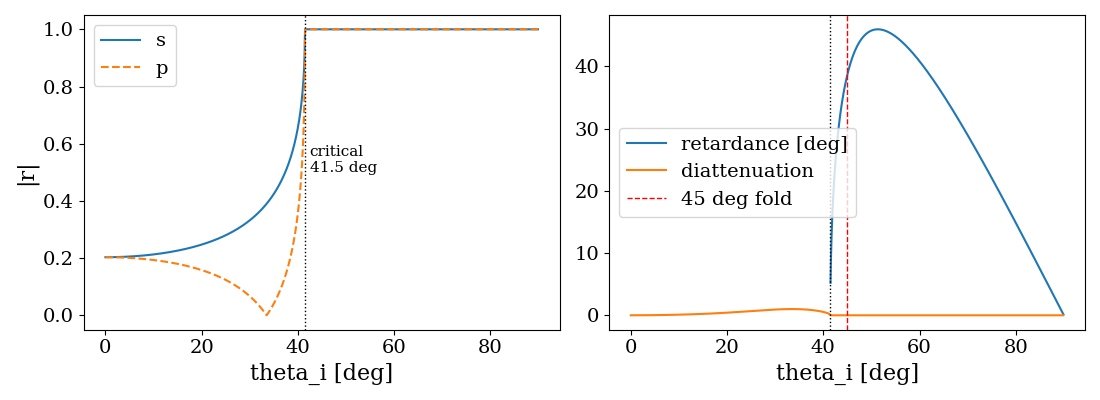

In [11]:
# ---- TIR version: glass -> air, e.g. a right-angle prism ----

n_glass = 1.5101                    # N-BK7 at 852 nm; 1.4525 for fused silica
n_rel = complex(1.0 / n_glass)      # relative index, MUST be complex
theta_c = np.degrees(np.arcsin(n_rel.real))

theta = np.radians(np.linspace(0, 89.9, 2000))

q = np.sqrt(n_rel**2 - np.sin(theta)**2)
q = np.where(q.imag < 0, -q, q)     # branch: decaying evanescent wave
r_s = (np.cos(theta) - q) / (np.cos(theta) + q)
r_p = (n_rel**2 * np.cos(theta) - q) / (n_rel**2 * np.cos(theta) + q)

tir = np.degrees(theta) > theta_c   # only this region is a working fold

phi_s = np.angle(r_s)
phi_p = np.pi + np.angle(r_p)
D = (abs(r_s)**2 - abs(r_p)**2) / (abs(r_s)**2 + abs(r_p)**2)
delta = np.angle(r_s) - np.angle(r_p)      # no unwrap needed above critical

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].plot(np.degrees(theta), abs(r_s), label='s')
ax[0].plot(np.degrees(theta), abs(r_p), '--', label='p')
ax[0].axvline(theta_c, color='k', ls=':', lw=1)
ax[0].text(theta_c + 1, 0.5, f'critical\n{theta_c:.1f} deg', fontsize=11)
ax[0].set_xlabel('theta_i [deg]'); ax[0].set_ylabel('|r|'); ax[0].legend()

ax[1].plot(np.degrees(theta)[tir], np.degrees(delta)[tir], label='retardance [deg]')
ax[1].plot(np.degrees(theta), D, label='diattenuation')
ax[1].axvline(theta_c, color='k', ls=':', lw=1)
ax[1].axvline(45.0, color='r', ls='--', lw=1, label='45 deg fold')
ax[1].set_xlabel('theta_i [deg]'); ax[1].legend()

i45 = np.argmin(abs(np.degrees(theta) - 45.0))
ipk = np.nanargmax(np.where(tir, np.degrees(delta), np.nan))
print(f'critical angle      {theta_c:.2f} deg   (margin at 45 deg fold: {45-theta_c:.2f} deg)')
print(f'retardance at 45    {np.degrees(delta)[i45]:.2f} deg')
print(f'peak retardance     {np.degrees(delta)[ipk]:.2f} deg at '
      f'{np.degrees(theta)[ipk]:.2f} deg  (Fresnel rhomb angle)')
plt.tight_layout()

at 45 deg:  |r_s| = 0.9892   |r_p| = 0.9786
            diattenuation = 0.0108   retardance = 15.71 deg


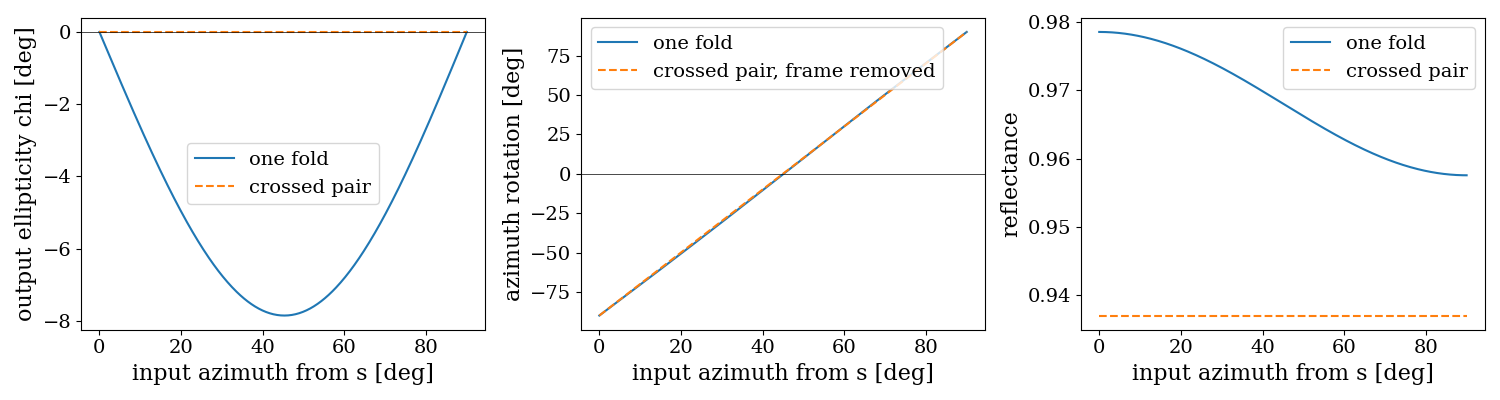

In [12]:
# ---- fixed 45 deg AOI, sweep input linear polarization from s to p ----

theta_45 = np.radians(45.0)

q45 = np.sqrt(n_metal**2 - np.sin(theta_45)**2)
if q45.real < 0:
    q45 = -q45
rs45 = (np.cos(theta_45) - q45) / (np.cos(theta_45) + q45)
rp45 = (n_metal**2 * np.cos(theta_45) - q45) / (n_metal**2 * np.cos(theta_45) + q45)

# Jones matrix of one fold, in the tracked s/p basis.
# The minus sign on rp is the same pi that phi_p carries in the cell above.
J = np.diag([rs45, -rp45])

# 90 deg basis rotation between the two folds: fold 1 s-axis becomes fold 2 p-axis
R90 = np.array([[0.0, 1.0], [-1.0, 0.0]])

J_pair = J @ R90 @ J          # crossed folds, z -> x -> y

D45 = (abs(rs45)**2 - abs(rp45)**2) / (abs(rs45)**2 + abs(rp45)**2)
delta45 = np.angle(-rp45) - np.angle(rs45)
print(f'at 45 deg:  |r_s| = {abs(rs45):.4f}   |r_p| = {abs(rp45):.4f}')
print(f'            diattenuation = {D45:.4f}   retardance = {np.degrees(delta45):.2f} deg')

az = np.radians(np.linspace(0.0, 90.0, 400))      # 0 = pure s, 90 = pure p
E_in = np.stack([np.cos(az), np.sin(az)]).astype(complex)


def stokes(E):
    a, b = E[0], E[1]
    S0 = abs(a)**2 + abs(b)**2
    S1 = abs(a)**2 - abs(b)**2
    S2 = 2 * np.real(a * np.conj(b))
    S3 = 2 * np.imag(a * np.conj(b))
    return S0, S1, S2, S3


def readout(E):
    """Reflectance, azimuth [deg], ellipticity angle [deg]."""
    S0, S1, S2, S3 = stokes(E)
    P = np.sqrt(S1**2 + S2**2 + S3**2)
    psi = np.degrees(0.5 * np.arctan2(S2, S1))
    chi = np.degrees(0.5 * np.arcsin(np.clip(S3 / P, -1.0, 1.0)))
    return S0, psi, chi


R_one, psi_one, chi_one = readout(J @ E_in)
R_two, psi_two, chi_two = readout(J_pair @ E_in)

az_deg = np.degrees(az)
psi_in = 90.0 - az_deg                 # input azimuth in the same S1/S2 sign convention

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].plot(az_deg, chi_one, label='one fold')
ax[0].plot(az_deg, chi_two, '--', label='crossed pair')
ax[0].axhline(0, color='k', lw=0.5)
ax[0].set_xlabel('input azimuth from s [deg]')
ax[0].set_ylabel('output ellipticity chi [deg]')
ax[0].legend()

ax[1].plot(az_deg, psi_one - psi_in, label='one fold')
ax[1].plot(az_deg, psi_two - psi_in + 90.0, '--', label='crossed pair, frame removed')
ax[1].axhline(0, color='k', lw=0.5)
ax[1].set_xlabel('input azimuth from s [deg]')
ax[1].set_ylabel('azimuth rotation [deg]')
ax[1].legend()

ax[2].plot(az_deg, R_one, label='one fold')
ax[2].plot(az_deg, R_two, '--', label='crossed pair')
ax[2].set_xlabel('input azimuth from s [deg]')
ax[2].set_ylabel('reflectance')
ax[2].legend()

plt.tight_layout()

at 45 deg:  |r_s| = 0.9892   |r_p| = 0.9786
            diattenuation = 0.0108   retardance = 15.71 deg


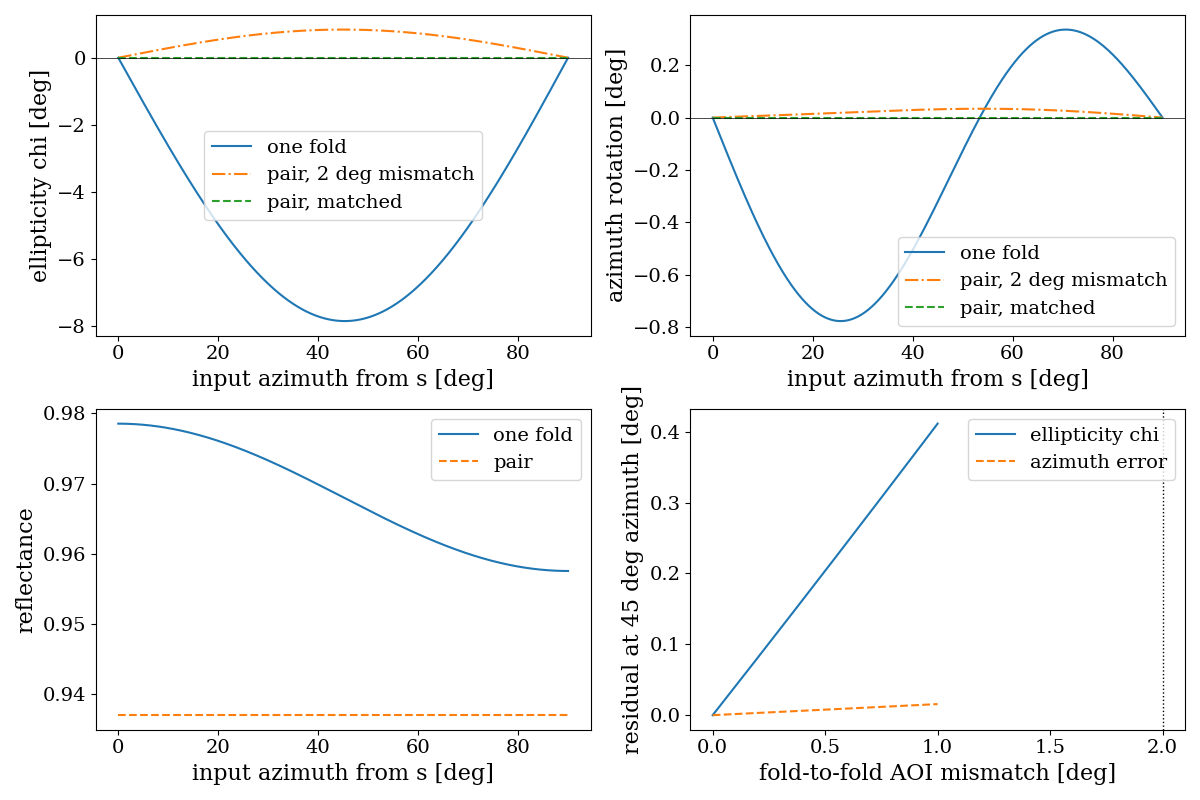

In [16]:
# ---- gold mirror, 45 deg AOI, sweep input polarization, with fold mismatch ----

n_metal = 0.207 + 5.07j               # gold at 852 nm
MISMATCH = 2                        # deg of AOI error on the second fold


def fold_jones(theta_deg):
    """Jones matrix of one fold, in the tracked s/p basis."""
    th = np.radians(theta_deg)
    q = np.sqrt(n_metal**2 - np.sin(th)**2)
    if q.imag < 0:                    # decaying wave into the metal
        q = -q
    rs = (np.cos(th) - q) / (np.cos(th) + q)
    rp = (n_metal**2 * np.cos(th) - q) / (n_metal**2 * np.cos(th) + q)
    return np.diag([rs, -rp]), rs, rp  # minus on rp = the pi in phi_p


R90 = np.array([[0.0, 1.0], [-1.0, 0.0]])

J, rs45, rp45 = fold_jones(45.0)
J_mm, _, _ = fold_jones(45.0 + MISMATCH)
J_pair = J @ R90 @ J
J_mis = J_mm @ R90 @ J

D45 = (abs(rs45)**2 - abs(rp45)**2) / (abs(rs45)**2 + abs(rp45)**2)
delta45 = np.angle(-rp45) - np.angle(rs45)
print(f'at 45 deg:  |r_s| = {abs(rs45):.4f}   |r_p| = {abs(rp45):.4f}')
print(f'            diattenuation = {D45:.4f}   retardance = {np.degrees(delta45):.2f} deg')

az = np.radians(np.linspace(0.0, 90.0, 400))
az_deg = np.degrees(az)
E_in = np.stack([np.cos(az), np.sin(az)]).astype(complex)


def readout(E):
    a, b = E[0], E[1]
    S0 = abs(a)**2 + abs(b)**2
    S1 = abs(a)**2 - abs(b)**2
    S2 = 2 * np.real(a * np.conj(b))
    S3 = 2 * np.imag(a * np.conj(b))
    P = np.sqrt(S1**2 + S2**2 + S3**2)
    psi = np.degrees(0.5 * np.arctan2(S2, S1))
    chi = np.degrees(0.5 * np.arcsin(np.clip(S3 / P, -1.0, 1.0)))
    return S0, psi, chi


def wrap(d):
    """Azimuth is defined mod 180; fold differences into (-90, 90]."""
    return ((d + 90.0) % 180.0) - 90.0


def ext_db(chi_deg):
    return -10 * np.log10(np.clip(np.tan(np.radians(chi_deg))**2, 1e-12, None))


R_one, psi_one, chi_one = readout(J @ E_in)
R_pair, psi_pair, chi_pair = readout(J_pair @ E_in)
R_mis, psi_mis, chi_mis = readout(J_mis @ E_in)

rot_one = wrap(psi_one - az_deg)               # input azimuth IS az_deg
rot_pair = wrap(psi_pair - (az_deg - 90.0))    # -90 removes the frame relabel
rot_mis = wrap(psi_mis - (az_deg - 90.0))

# tolerance sweep at the worst-case input azimuth
mm = np.linspace(0.0, 1.0, 150)
E45 = np.array([[np.cos(np.pi/4)], [np.sin(np.pi/4)]], dtype=complex)
tol_chi, tol_rot = [], []
for d in mm:
    _, p, c = readout(fold_jones(45.0 + d)[0] @ R90 @ J @ E45)
    tol_chi.append(abs(c[0]))
    tol_rot.append(abs(wrap(p[0] - (45.0 - 90.0))))

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

ax[0, 0].plot(az_deg, chi_one, label='one fold')
ax[0, 0].plot(az_deg, chi_mis, '-.', label=f'pair, {MISMATCH} deg mismatch')
ax[0, 0].plot(az_deg, chi_pair, '--', label='pair, matched')
ax[0, 0].axhline(0, color='k', lw=0.5)
ax[0, 0].set_xlabel('input azimuth from s [deg]')
ax[0, 0].set_ylabel('ellipticity chi [deg]')
ax[0, 0].legend()

ax[0, 1].plot(az_deg, rot_one, label='one fold')
ax[0, 1].plot(az_deg, rot_mis, '-.', label=f'pair, {MISMATCH} deg mismatch')
ax[0, 1].plot(az_deg, rot_pair, '--', label='pair, matched')
ax[0, 1].axhline(0, color='k', lw=0.5)
ax[0, 1].set_xlabel('input azimuth from s [deg]')
ax[0, 1].set_ylabel('azimuth rotation [deg]')
ax[0, 1].legend()

ax[1, 0].plot(az_deg, R_one, label='one fold')
ax[1, 0].plot(az_deg, R_pair, '--', label='pair')
ax[1, 0].set_xlabel('input azimuth from s [deg]')
ax[1, 0].set_ylabel('reflectance')
ax[1, 0].legend()

ax[1, 1].plot(mm, tol_chi, label='ellipticity chi')
ax[1, 1].plot(mm, tol_rot, '--', label='azimuth error')
ax[1, 1].axvline(MISMATCH, color='k', ls=':', lw=1)
ax[1, 1].set_xlabel('fold-to-fold AOI mismatch [deg]')
ax[1, 1].set_ylabel('residual at 45 deg azimuth [deg]')
ax[1, 1].legend()

plt.tight_layout()

n_glass = 1.5101   critical angle = 41.47 deg   margin = 3.53 deg
at 45 deg:  |r_s| = 1.000000   |r_p| = 1.000000
            diattenuation = 1.11e-16   retardance = 141.35 deg


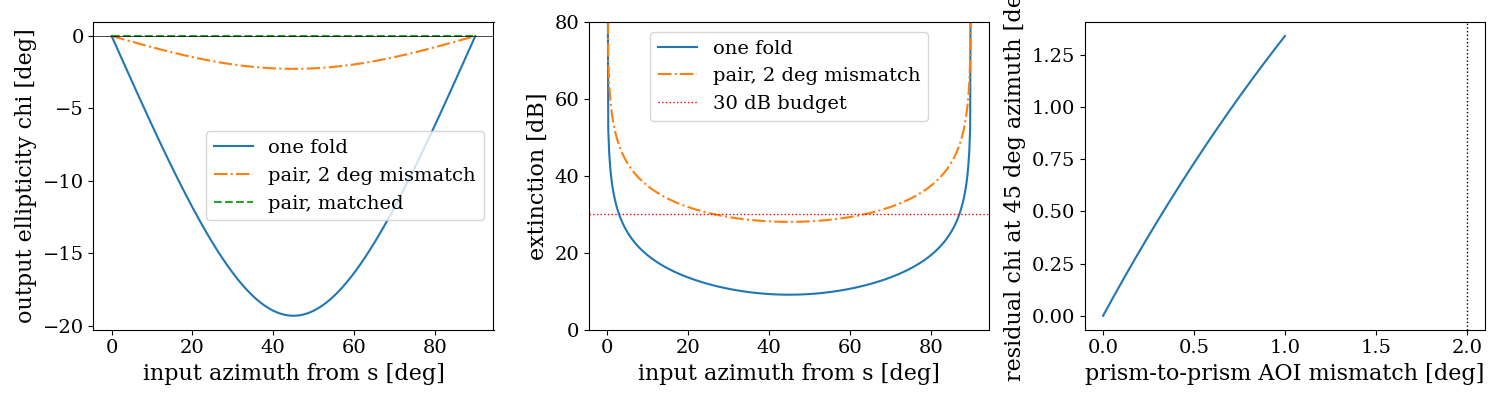

In [15]:
# ---- TIR prism, 45 deg AOI, sweep input linear polarization from s to p ----

n_glass = 1.5101                      # N-BK7 at 852 nm; 1.4525 for fused silica
n_rel = complex(1.0 / n_glass)        # glass -> air; MUST be complex or sqrt gives nan
theta_c = np.degrees(np.arcsin(n_rel.real))


def fold_jones(theta_deg):
    """Jones matrix of one TIR fold, in the tracked s/p basis."""
    th = np.radians(theta_deg)
    q = np.sqrt(n_rel**2 - np.sin(th)**2)
    if q.imag < 0:                    # decaying evanescent wave, NOT q.real
        q = -q
    rs = (np.cos(th) - q) / (np.cos(th) + q)
    rp = (n_rel**2 * np.cos(th) - q) / (n_rel**2 * np.cos(th) + q)
    return np.diag([rs, -rp]), rs, rp  # minus on rp = the pi in phi_p


R90 = np.array([[0.0, 1.0], [-1.0, 0.0]])   # 90 deg basis rotation between folds
MISMATCH = 2                              # deg of AOI error on the second prism

J, rs45, rp45 = fold_jones(45.0)
J_mm, _, _ = fold_jones(45.0 + MISMATCH)
J_pair = J @ R90 @ J                        # matched crossed folds, z -> x -> y
J_mis = J_mm @ R90 @ J                      # realistic pair

D45 = (abs(rs45)**2 - abs(rp45)**2) / (abs(rs45)**2 + abs(rp45)**2)
delta45 = np.angle(-rp45) - np.angle(rs45)
print(f'n_glass = {n_glass}   critical angle = {theta_c:.2f} deg   margin = {45-theta_c:.2f} deg')
print(f'at 45 deg:  |r_s| = {abs(rs45):.6f}   |r_p| = {abs(rp45):.6f}')
print(f'            diattenuation = {D45:.2e}   retardance = {np.degrees(delta45):.2f} deg')

az = np.radians(np.linspace(0.0, 90.0, 400))
E_in = np.stack([np.cos(az), np.sin(az)]).astype(complex)


def readout(E):
    a, b = E[0], E[1]
    S0 = abs(a)**2 + abs(b)**2
    S1 = abs(a)**2 - abs(b)**2
    S2 = 2 * np.real(a * np.conj(b))
    S3 = 2 * np.imag(a * np.conj(b))
    P = np.sqrt(S1**2 + S2**2 + S3**2)
    psi = np.degrees(0.5 * np.arctan2(S2, S1))
    chi = np.degrees(0.5 * np.arcsin(np.clip(S3 / P, -1.0, 1.0)))
    return S0, psi, chi


def ext_db(chi_deg):
    return -10 * np.log10(np.clip(np.tan(np.radians(chi_deg))**2, 1e-12, None))


_, _, chi_one = readout(J @ E_in)
_, _, chi_pair = readout(J_pair @ E_in)
_, _, chi_mis = readout(J_mis @ E_in)

# tolerance curve: worst-case input azimuth, sweep the mismatch
mm = np.linspace(0.0, 1.0, 200)
E45 = np.array([[np.cos(np.pi/4)], [np.sin(np.pi/4)]], dtype=complex)
chi_tol = np.array([abs(readout(fold_jones(45.0 + d)[0] @ R90 @ J @ E45)[2][0])
                    for d in mm])

az_deg = np.degrees(az)
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].plot(az_deg, chi_one, label='one fold')
ax[0].plot(az_deg, chi_mis, '-.', label=f'pair, {MISMATCH} deg mismatch')
ax[0].plot(az_deg, chi_pair, '--', label='pair, matched')
ax[0].axhline(0, color='k', lw=0.5)
ax[0].set_xlabel('input azimuth from s [deg]')
ax[0].set_ylabel('output ellipticity chi [deg]')
ax[0].legend()

ax[1].plot(az_deg, ext_db(chi_one), label='one fold')
ax[1].plot(az_deg, ext_db(chi_mis), '-.', label=f'pair, {MISMATCH} deg mismatch')
ax[1].axhline(30, color='r', ls=':', lw=1, label='30 dB budget')
ax[1].set_xlabel('input azimuth from s [deg]')
ax[1].set_ylabel('extinction [dB]')
ax[1].set_ylim(0, 80)
ax[1].legend()

ax[2].plot(mm, chi_tol)
ax[2].axvline(MISMATCH, color='k', ls=':', lw=1)
ax[2].set_xlabel('prism-to-prism AOI mismatch [deg]')
ax[2].set_ylabel('residual chi at 45 deg azimuth [deg]')

plt.tight_layout()